In [1]:
import sys
import os

# Lấy đường dẫn tuyệt đối của thư mục cha (src)
# Đi lên một cấp từ thư mục 'notebook'
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Thêm thư mục 'src' (chứa utils.py) vào Python system path
sys.path.append(parent_dir)

# Bây giờ bạn có thể import module utils và sử dụng các hàm/class trong đó
from src.utils import preprocess_text

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
train_dataset = pd.read_csv(
    r'../data/train.csv'
)
train_dataset.head(5)

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


# EDA THIS DATASET

## 1. Count label

In [4]:
def count_target_label(
    df: pd.DataFrame
):
    target_counts = df['target'].value_counts()
    label0 = target_counts.get(0, 0)
    label1 = target_counts.get(1, 0)

    result_df = pd.DataFrame({
        'label 0': [label0],
        'label 1': [label1]
    })
    print(result_df)


    plt.bar(['label 0', 'label 1'], [label0, label1])
    plt.title('Distribution of different labels')
    plt.show()

    return None

   label 0  label 1
0     4342     3271


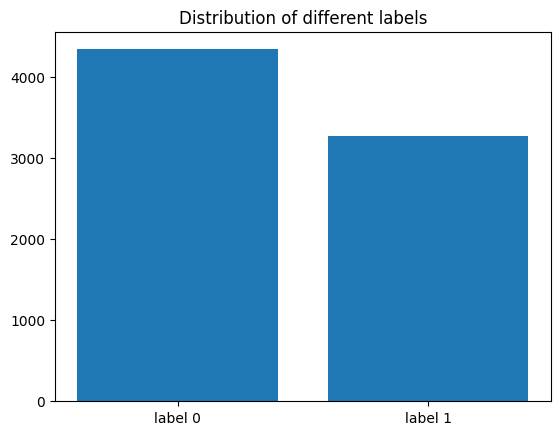

In [5]:
count_target_label(train_dataset)

## 1. Hiểu dữ liệu

### 1.1. Finding out missing values

In [6]:
def count_missing_value(df):
    """
    Đếm và in ra số lượng (và tỷ lệ phần trăm) giá trị thiếu (NaN) 
    cho từng cột trong DataFrame.
    """
    print("--- Thống kê Giá trị Thiếu (Missing Values) ---")
    
    total_rows = len(df)

    total_missing = []
    rate_missing = []
    
    for column in df.columns:
        number_of_missing_value = df[column].isnull().sum()
        missing_rate = 0.0 if number_of_missing_value == 0 else np.round((number_of_missing_value / total_rows) * 100, 2)

        total_missing.append(number_of_missing_value)
        rate_missing.append(missing_rate)
        

    
    return pd.DataFrame({
        'column': df.columns,
        'total': total_rows,
        'number_of_missing': total_missing,
        'missing_rate': rate_missing
    })

In [7]:
missing_rate = count_missing_value(train_dataset)
missing_rate[missing_rate['number_of_missing'] > 0]

--- Thống kê Giá trị Thiếu (Missing Values) ---


,column,total,number_of_missing,missing_rate
1,keyword,7613,61,0.80
2,location,7613,2533,33.27


### 1.2. Các token phổ biến nhất theo lớp

In [8]:
import pandas as pd
# Giả sử train_dataset đã được load và preprocess_text đã được định nghĩa

# 1. Áp dụng Tokenization và tính độ dài câu
# Gán cột mới 'token_list' và 'token_count' trực tiếp vào train_dataset
train_dataset['token_list'] = train_dataset['text'].apply(preprocess_text)
train_dataset['token_count'] = train_dataset['token_list'].apply(len)

# 2. Phân nhóm theo 'target' và tính toán thống kê
token_stats_by_class = train_dataset.groupby('target')['token_count'].agg(
    ['count', 'mean', 'median', 'min', 'max', 'std']
).reset_index()

print("--- Thống kê Độ dài Token theo Lớp ---")
print(token_stats_by_class)

--- Thống kê Độ dài Token theo Lớp ---
   target  count       mean  median  min  max       std
0       0   4342  15.380930    15.0    1   72  7.163023
1       1   3271  15.600122    15.0    1   38  6.057294


## 2. Làm sạch dữ liệu

### 2.1. Tiền xử lý dữ liệu

In [9]:
from src.utils import preprocess_text

In [10]:
def preprocess_dataset(df):
    preprocessed_df = df.copy()
    for col_name in preprocessed_df.columns:
        preprocessed_df[col_name] = preprocessed_df[col_name].apply(preprocess_text)
    
    return preprocessed_df

In [11]:
preprocess_dataset(train_dataset)
train_dataset

,id,keyword,location,text,target,token_list,token_count
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1,"[our, deeds, are, the, reason, of, this, #eart...",13
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,"[forest, fire, near, la, ronge, sask, ., canada]",8
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1,"[all, residents, asked, to, 'shelter, in, plac...",23
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1,"[13, ,, 000, people, receive, #wildfires, evac...",10
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1,"[just, got, sent, this, photo, from, ruby, #al...",16
...,...,...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1,"[two, giant, cranes, holding, a, bridge, colla...",10
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1,"[the, out, of, control, wild, fires, in, calif...",20
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1,"[m1, ., 94, [01:04, utc], ?, 5km, s, of, volca...",12
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1,"[police, investigating, after, an, e-bike, col...",21
